# PUCT and Dirichlet Noise, Up Close

In the [AlphaZero notebook](alphazero_tictactoe.ipynb), the search picks moves with the **PUCT** rule, the
root gets **Dirichlet noise**, and the network's policy head trains on the resulting visit counts. Here we lift
that exact selection machinery out of the tree and study it with **one fixed state** and 4 actions — no
network, no tree, no self-play. Same formula, same noise parameters (`c_puct=1.5`, `alpha=0.3`, `eps=0.25`,
as in the other notebook), nothing else to distract us.

## 1. The PUCT formula, piece by piece

With a single state we drop $s$ from the rule used in the AlphaZero notebook:

$$a^* = \arg\max_a \left[ Q(a) + c_{\text{puct}}\, P(a)\, \frac{\sqrt{N}}{1 + N(a)} \right],
\qquad N = \sum_a N(a).$$

Each piece has one job:

| Piece | Meaning | Role |
|---|---|---|
| $Q(a)$ | mean reward seen from action $a$ so far | **exploit** — "what has worked" |
| $P(a)$ | prior probability of $a$ | where the search looks *first*; in AlphaZero this is the network's policy head |
| $N(a)$ | times $a$ has been tried; $N$ is the total | experience counter |
| $\displaystyle U(a) = c_{\text{puct}}\,P(a)\,\frac{\sqrt{N}}{1+N(a)}$ | exploration bonus | large when the prior likes $a$ but it is under-tried; decays as $N(a)$ grows |
| $c_{\text{puct}}$ | exploration constant (1.5 here) | the dial between the two terms |

Two facts worth staring at:

- **The bonus is prior-weighted.** An action the prior rates highly gets a big bonus while untried; an action
the prior dismisses must earn its visits through $Q$. The search trusts the prior *until evidence arrives*.
- **Nobody is ignored forever.** Fix $N(a)$ and let $N \to \infty$: the bonus grows like $\sqrt{N}$, so every
action is eventually revisited infinitely often. PUCT cannot permanently lock onto a wrong arm — the only
question is *how long* a bad prior delays the discovery. (§5 measures exactly that.)

In [1]:
# A worked step, by hand: given this search state, what does PUCT pick?
import numpy as np

prior = np.array([0.5, 0.3, 0.1, 0.1])   # P(a): trusts arm 0, doubts arms 2 and 3
N = np.array([10, 5, 1, 0])              # visit counts so far
Q = np.array([0.30, 0.55, 0.80, 0.00])   # mean rewards so far (arm 3 untried)
C_PUCT = 1.5

Ntot = N.sum()
U = C_PUCT * prior * np.sqrt(Ntot) / (1 + N)
print(f"{'arm':<5}{'Q(a)':<8}{'U(a)':<8}{'Q+U':<8}")
for a in range(4):
    print(f"{a:<5}{Q[a]:<8.2f}{U[a]:<8.3f}{Q[a] + U[a]:<8.3f}")
print("PUCT selects arm", int(np.argmax(Q + U)))

# Note: arm 3 has Q=0 (never tried) yet gets the largest bonus U=0.600 --
# the prior is weak (0.1) but 1/(1+0) and sqrt(N) compensate. Arm 2 still wins
# on merit. The bonus promotes the untried without being reckless.

arm  Q(a)    U(a)    Q+U     
0    0.30    0.273   0.573   
1    0.55    0.300   0.850   
2    0.80    0.300   1.100   
3    0.00    0.600   0.600   
PUCT selects arm 2


## 2. Dirichlet noise

At the root of every search, AlphaZero perturbs the prior *once*:

$$P(a) \leftarrow (1 - \varepsilon)\, P(a) + \varepsilon\, \eta_a,
\qquad \eta \sim \text{Dir}(\alpha),$$

with $\varepsilon = 0.25$ and $\alpha = 0.3$ (the values in the other notebook; the AlphaZero paper uses the
same $\varepsilon$ and $\alpha = 0.3$ / $0.15$ / $0.03$ for chess / shogi / Go).

Why it matters:

- **Without noise, identical positions search identically.** Every self-play game from the same opening would
explore the same lines and produce the same training targets — wasted games. Noise makes each search commit to
a *different* "what if" early on, so the training data covers the space.
- **Small $\alpha$ means spiky samples.** $\text{Dir}(0.3)$ doesn't produce near-uniform vectors; it puts most
of the noise mass on one or two randomly chosen actions. Each game gets a different favorite to investigate.
- **It touches only the prior, not $Q$.** Noise changes *where the search looks first*, never the value
estimates. Its influence fades as real visit counts accumulate — exactly as it should.

The plot below: our prior, plus three independent noise samples. Notice how each sample anoints a different arm.

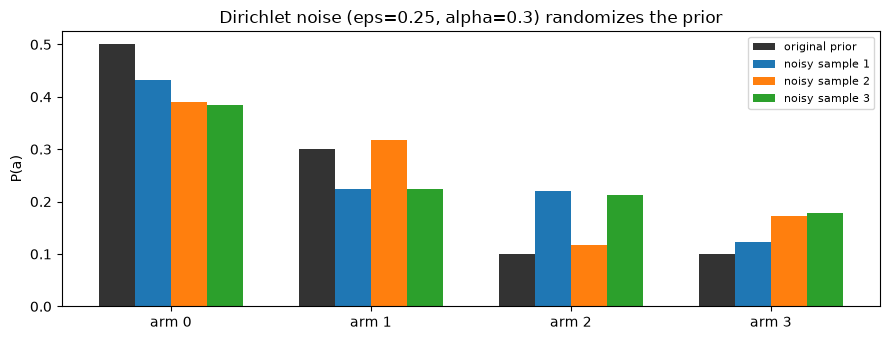

In [2]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
EPS, ALPHA = 0.25, 0.3

fig, ax = plt.subplots(figsize=(9, 3.5))
x = np.arange(4)
w = 0.18
ax.bar(x - 1.5*w, prior, width=w, label="original prior", color="black", alpha=0.8)
for i in range(3):
    eta = rng.dirichlet(np.full(4, ALPHA))
    noisy = (1 - EPS) * prior + EPS * eta
    ax.bar(x + (i - 0.5)*w, noisy, width=w, label=f"noisy sample {i+1}")
ax.set_xticks(x); ax.set_xticklabels([f"arm {a}" for a in range(4)])
ax.set_ylabel("P(a)"); ax.set_title("Dirichlet noise (eps=0.25, alpha=0.3) randomizes the prior")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 3. Watching PUCT search

Now the loop itself. True (unknown) mean rewards, a *misleading* prior that undervalues the best arm, and
Bernoulli payouts (win/loss, like game outcomes in AlphaZero):

- each step: pick $a^*$ by PUCT, observe a stochastic reward, update $N(a)$ and the running mean $Q(a)$.

(At $t=0$ all bonuses are 0, so the tie breaks to arm 0 — from $t=1$ on, the prior shapes the search.)

visits:        [  54   61 2866   19]
Q estimates:   [0.148 0.492 0.899 0.474]  truth: [0.2 0.5 0.9 0.4]
visit shares:  [0.018 0.02  0.955 0.006]


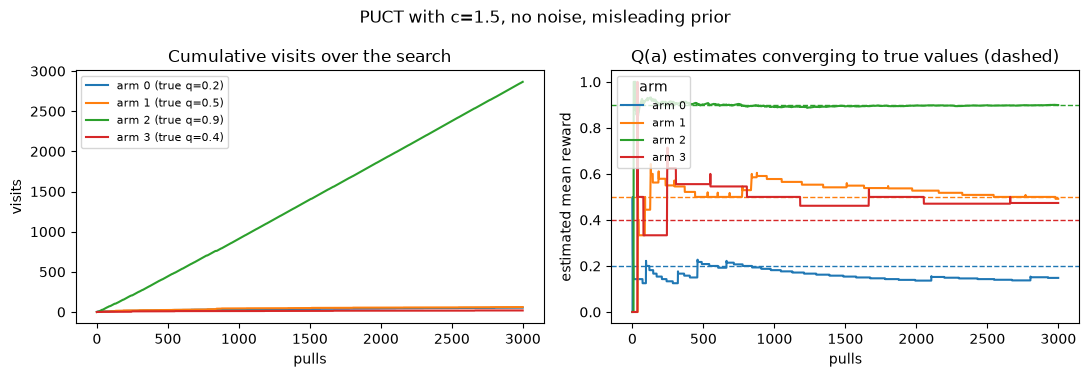

In [3]:
def run_puct(T, c_puct, prior, eps=0.0, alpha=0.3, seed=0):
    # PUCT selection on one fixed state. Returns visits, Q-estimates, used prior, histories.
    rng = np.random.default_rng(seed)
    n = len(prior)
    P = prior.copy()
    if eps > 0:
        P = (1 - eps) * P + eps * rng.dirichlet(np.full(n, alpha))
    N = np.zeros(n)
    Q = np.zeros(n)
    N_hist = np.zeros((T, n))
    Q_hist = np.zeros((T, n))
    for t in range(T):
        Ntot = N.sum()
        U = c_puct * P * np.sqrt(Ntot) / (1 + N)   # exact PUCT bonus
        a = int(np.argmax(Q + U))
        r = 1.0 if rng.random() < q_true[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]                  # running mean
        N_hist[t] = N
        Q_hist[t] = Q
    return N, Q, P, N_hist, Q_hist

q_true = np.array([0.2, 0.5, 0.9, 0.4])   # arm 2 is truly best ...
prior  = np.array([0.5, 0.3, 0.1, 0.1])   # ... but the prior barely believes it
T = 3000

N, Q, P_used, N_hist, Q_hist = run_puct(T, 1.5, prior, seed=1)
print("visits:       ", N.astype(int))
print("Q estimates:  ", np.round(Q, 3), " truth:", q_true)
print("visit shares: ", np.round(N / T, 3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
t = np.arange(T)
for a in range(4):
    ax[0].plot(t, N_hist[:, a], label=f"arm {a} (true q={q_true[a]})")
ax[0].set_title("Cumulative visits over the search")
ax[0].set_xlabel("pulls"); ax[0].set_ylabel("visits"); ax[0].legend(fontsize=8)

for a in range(4):
    ax[1].plot(t, Q_hist[:, a], label=f"arm {a}")
    ax[1].axhline(q_true[a], ls="--", lw=1, color=f"C{a}")
ax[1].set_title("Q(a) estimates converging to true values (dashed)")
ax[1].set_xlabel("pulls"); ax[1].set_ylabel("estimated mean reward"); ax[1].legend(fontsize=8,
                                                                                  title="arm")
fig.suptitle("PUCT with c=1.5, no noise, misleading prior", fontsize=12)
fig.tight_layout(); plt.show()

# Reading the plot: the prior's favorite (arm 0) is tried first, but its Q collapses
# toward 0.2 while arm 2's Q climbs toward 0.9 -- and the visit counts follow the
# evidence, not the prior. In AlphaZero these root visit counts, normalized, become
# the policy target that trains the network.

## 4. The $c_{\text{puct}}$ dial

Same setup, three values of $c_{\text{puct}}$. Small $c$ trusts $Q$ quickly (greedy);
large $c$ keeps spreading visits according to the prior (exploratory).

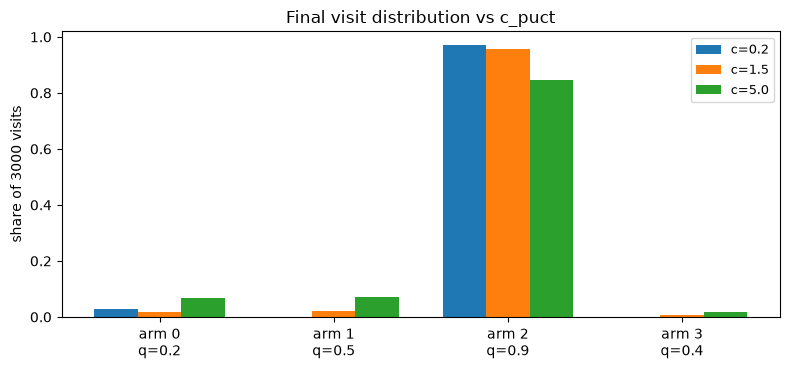

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))
cs = [0.2, 1.5, 5.0]
x = np.arange(4); w = 0.25
for i, c in enumerate(cs):
    N_c, _, _, _, _ = run_puct(T, c, prior, seed=1)
    ax.bar(x + (i - 1) * w, N_c / T, width=w, label=f"c={c}")
ax.set_xticks(x); ax.set_xticklabels([f"arm {a}\nq={q_true[a]}" for a in range(4)])
ax.set_ylabel("share of 3000 visits"); ax.set_title("Final visit distribution vs c_puct")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

# c=0.2 concentrates on the winner fast -- efficient, but with a worse prior or noisier
# rewards it could commit before the evidence is in. c=5.0 keeps "checking" the losers
# long after they are settled. c=1.5 is the middle path the other notebook uses.

## 5. What the noise buys us

The misleading prior gives the best arm (arm 2) only $P = 0.1$. How long until PUCT discovers it —
with and without Dirichlet noise on the prior? Averaged over 12 random seeds.

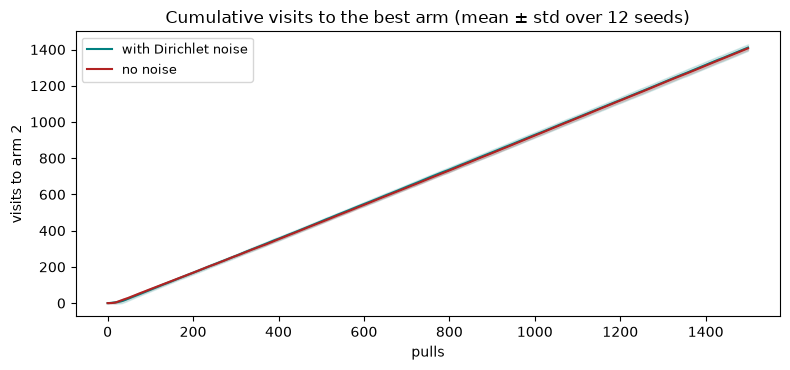

In [5]:
SEEDS = 12
T2 = 1500
vis_noisy = np.zeros((SEEDS, T2))
vis_plain = np.zeros((SEEDS, T2))
for s in range(SEEDS):
    _, _, _, Nh, _ = run_puct(T2, 1.5, prior, eps=0.25, alpha=0.3, seed=s)
    vis_noisy[s] = Nh[:, 2]
    _, _, _, Nh, _ = run_puct(T2, 1.5, prior, eps=0.0, seed=s)
    vis_plain[s] = Nh[:, 2]

fig, ax = plt.subplots(figsize=(8, 3.8))
t = np.arange(T2)
for data, label, col in [(vis_noisy, "with Dirichlet noise", "teal"),
                         (vis_plain, "no noise", "firebrick")]:
    m, sd = data.mean(0), data.std(0)
    ax.plot(t, m, label=label, color=col)
    ax.fill_between(t, m - sd, m + sd, color=col, alpha=0.15)
ax.set_title("Cumulative visits to the best arm (mean ± std over 12 seeds)")
ax.set_xlabel("pulls"); ax.set_ylabel("visits to arm 2"); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

# The noise doesn't change where PUCT ends up -- the bonus already guarantees every arm
# is revisited forever -- it changes *how fast* a dismissed arm gets its first serious
# look. In AlphaZero that speed is diversity: different noisy priors in different games
# mean different lines explored, which is what makes the self-play training data worth
# learning from.

## 6. Putting it back in the tree

Everything above was one node. In the AlphaZero notebook this exact rule runs at **every** node of the
search tree, with the node's own $Q$, $N$, and the network's $P(\cdot \mid s)$:

- each search adds Dirichlet noise to the **root** prior only, then runs hundreds of PUCT selections;
- the root's visit counts, normalized (with temperature), become the improved policy $\pi$ that the network's
policy head trains against;
- the network's new $P$ then guides the *next* round of searches.

That is the policy-iteration loop: **search improves the policy** (visits $\to$ targets), **the policy improves
the search** (priors $\to$ PUCT). This notebook was the selection step of that loop, isolated and slowed down
enough to watch.